In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

print("✅ Data loaded!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

✅ Data loaded!
Training samples : 1318
Testing samples  : 330
Number of features: 18


In [2]:
# Model 1 - Logistic Regression (simple, fast, good baseline)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [3]:
# Model 2 - Random Forest (ensemble of decision trees)
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

✅ Random Forest trained!


In [4]:
# Model 3 - XGBoost (usually the best performer)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained!")

✅ XGBoost trained!


In [5]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'AUC-ROC':>10}")
print("-" * 60)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'Accuracy': acc, 'F1': f1, 'AUC': auc}
    print(f"{name:<25} {acc:>10.3f} {f1:>10.3f} {auc:>10.3f}")

Model                       Accuracy   F1 Score    AUC-ROC
------------------------------------------------------------
Logistic Regression            0.942      0.941      0.986
Random Forest                  0.945      0.945      0.987
XGBoost                        0.945      0.945      0.989


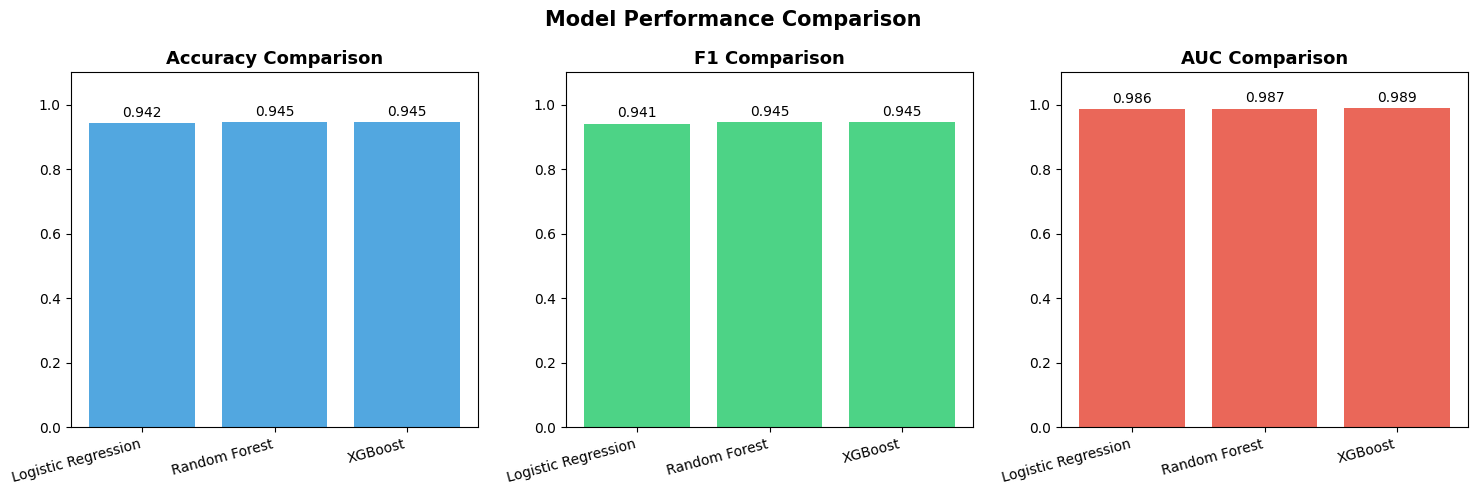

✅ Chart saved!


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'F1', 'AUC']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'F1', 'AUC']
colors  = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df['Model'], results_df[metric],
                color=colors[i], alpha=0.85)
    axes[i].set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_xticklabels(results_df['Model'], rotation=15, ha='right')
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()
print("✅ Chart saved!")

In [7]:
from sklearn.model_selection import GridSearchCV

# Parameters to try
param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.8, 1.0]
}

xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring='roc_auc', # optimize for AUC
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found:")
print(grid_search.best_params_)
print(f"\nBest AUC score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best parameters found:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Best AUC score: 0.9918


In [8]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("✅ Tuned XGBoost Performance:")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")

✅ Tuned XGBoost Performance:
  Accuracy : 0.9424
  F1 Score : 0.9422
  AUC-ROC  : 0.9874


In [9]:
joblib.dump(best_model, '../models/xgboost_final_model.pkl')
print("✅ Final model saved to models/xgboost_final_model.pkl")

✅ Final model saved to models/xgboost_final_model.pkl
